In [ ]:
import sys
sys.path.append('../')
import UTILS.utils as utils
import UTILS.utils_bert as utils_bert
import pandas as pd
import json

import google.generativeai as genai

from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

# PARAGRAPH CLASSIFICATION

In [3]:
all_paragraphs = pd.read_csv("../../Data/TEXT/ALL_PARAGRAPHS.csv")

In [ ]:
# GET LIST OF TOPICS FROM ALL DOCUMENTS
def topic_distillation_prompt(df):
    prompt = "Your task will be to distill a list of topics from the following documents: \n"
    for text in df["text"].to_list():
        prompt += "DOCUMENT: {" + text + "}\n"
    prompt += """
    Your response should be a JSON in the following format: {‘topics’: [‘topic1’, ‘topic2’, ‘topic3’]}
    Topics should not be too specific, but also not too general. For example, ‘food’ is too general, but
    ‘lemon cake’ is too specific. A topic does not need to be present in multiple documents. Please do not include any city names in the topics."""
    return prompt
    
prompt = topic_distillation_prompt(all_paragraphs)

In [38]:
genai.configure(api_key=utils.API_KEY())
model = genai.GenerativeModel('gemini-1.5-flash')

In [6]:
# GET LIST OF TOPICS (WILL CHANGE AT EVERY RUN)

response = model.generate_content(contents=[prompt])
print(response.text)

topics = json.loads("".join(response.text.split("\n")[1:-2]))["topics"]

NameError: name 'model' is not defined

In [39]:
## USE FINAL TOPICS
topics = utils.get_list_topics()

In [40]:
# ASSIGN ONE TOPIC TO DOCUMENT
def classification_prompt(document, topics):
    prompt = "Your task will be to classify the following document into one of the following topics:"
    prompt += "\nDOCUMENT : {" + document + "}\nTOPICS:\n"
    for i, topic in enumerate(topics):
        prompt += str(i) + " : " + topic + "\n"
    prompt += """
    Your response should be a JSON in the following format: {‘topic’: idx}
    The index should be the index of the topic in the list of topics."""
    return prompt


In [41]:
from tqdm import tqdm

def get_text_classification(df, topics, classification_num):
    classification = []
    for text in tqdm(df["text"].to_list()):
        prompt = classification_prompt(text, topics)
        response = model.generate_content(contents=[prompt])
        classification.append(response.text)
    index = "classificiation_" + str(classification_num)
    df[index] = classification

# RUN 3 TIMES TO ACCOUNT FOR RANDOMNESS
get_text_classification(all_paragraphs, topics, 0)
get_text_classification(all_paragraphs, topics, 1)
get_text_classification(all_paragraphs, topics, 2)

100%|██████████| 465/465 [03:33<00:00,  2.18it/s]


In [42]:
import ast

# EXTRACT TOPIC FROM JSON FORMATTING
def extract_topic(topic):
    topic = topic.replace("'", '"')
    try :
        topic.split("\"topic\": ")[1].split("}")[0]
    except:
        print(topic)
    return (topic.split("\"topic\": ")[1].split("}")[0])

all_paragraphs["classificiation_0"] = all_paragraphs["classificiation_0"].apply(lambda x : extract_topic(x))
all_paragraphs["classificiation_1"] = all_paragraphs["classificiation_1"].apply(lambda x : extract_topic(x))
all_paragraphs["classificiation_2"] = all_paragraphs["classificiation_2"].apply(lambda x : extract_topic(x))

In [43]:
# DETERMINE IF CLASSIFICATION IS THE SAME AMONG 3 RUNS
def test_row(row):
    return str(row["classificiation_0"]).strip() == str(row["classificiation_1"]).strip() and str(row["classificiation_2"]).strip() == str(row["classificiation_1"]).strip()

all_paragraphs["same_classification"] = all_paragraphs.apply(lambda x : test_row(x), axis=1)

In [44]:
len(all_paragraphs[all_paragraphs["same_classification"] == False])

31

In [45]:
# GET FINAL CLASSIFICATION FROM MAJORITY VOTE
def get_final_classification(row):
    if row["same_classification"]:
        return row["classificiation_1"]
    else:
        options = [
            int(row["classificiation_0"]),
            int(row["classificiation_1"]),
            int(row["classificiation_2"]) 
        ]
        return max(set(options), key=options.count)
    
all_paragraphs["class"] = all_paragraphs.apply(lambda x: get_final_classification(x), axis=1)

In [78]:
all_paragraphs.sample(20)

,chapter,paragraph,text,classificiation_0,classificiation_1,classificiation_2,same_classification,class
277,64,4,Notice the building on our left with the Ameri...,24,24,24,True,24
26,3,9,On that dock between the steamers and the shor...,22,22,22,True,22
130,28,2,Embroidery is a high art in China.\nIt is carr...,4,4,4,True,4
272,62,5,We saw on the city wall two dead Boxers;\nyou ...,2,2,2,True,2
192,40,4,"The ""The law distinctly states, with regard to...",7,7,7,True,7
382,80,6,"We will descend and enter at that middle door,...",13,13,13,True,13
86,16,3,Our more distant surroundings are considerably...,11,11,11,True,11
280,65,3,Do not forget that we are here looking at a fa...,9,9,9,True,9
452,98,5,After thanking him suitably for his hospitalit...,20,20,20,True,20
437,94,3,"There is a pretty pavilion at our right hand, ...",1,1,1,True,1


In [ ]:
df_to_save = all_paragraphs.drop(columns=['classificiation_0', 'classificiation_1', "classificiation_2", "same_classification"])
df_to_save["class_name"] = df_to_save["class"].apply(lambda x : topics[int(x)])
df_to_save.to_csv("../../Data/ALL_PARAGRAPHS_CLASSED.csv", index=False)

# CALCULATING COHERENCE SCORE

In [4]:
import pandas as pd

df_to_save = pd.read_csv("../../Data/ALL_PARAGRAPHS_CLASSED.csv")
classes = df_to_save["class_name"].to_list()

topics = utils.get_list_topics()
class_to_id = {cls: i for i, cls in enumerate(topics)}
numeric_classes = [class_to_id[cls] for cls in classes]

In [5]:
class_documents = df_to_save.groupby('class_name')['text'].apply(lambda x: ' '.join(x)).reset_index()
texts_for_tfidf = class_documents['text'].tolist()
class_labels = class_documents['class_name'].tolist()

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
class_term_matrix = vectorizer.fit_transform(texts_for_tfidf)
feature_names = vectorizer.get_feature_names_out()

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

tfidf_transformer = TfidfTransformer()
class_tfidf_scores = tfidf_transformer.fit_transform(class_term_matrix)

In [14]:
print("--- Manual Class-based TF-IDF Scores ---")
for i, class_name in enumerate(class_labels):
    # Get scores for the current class (row i in the TF-IDF matrix)
    scores = class_tfidf_scores[i].toarray().flatten()

    # Create a Series for easy sorting and mapping with words
    word_scores = pd.Series(scores, index=feature_names)

    # Sort in descending order and get top N words
    top_n_words = word_scores.nlargest(8) # Get top 10 words

    s = "\item" + "\\" + "v" + "space{-0.2cm} \\" + "textbf{" + str(class_name) + "} : ["
    l = []
    for k in top_n_words.items():
        l.append(k[0])
    s += ", ".join(l) + "]"
    print(s)


--- Manual Class-based TF-IDF Scores ---
\item\vspace{-0.2cm} \textbf{Agriculture and Farming} : [buffalo, plowman, rice, beast, plow, bamboo, beauty, water]
\item\vspace{-0.2cm} \textbf{Architecture and Building} : [pagoda, hall, city, temple, buildings, wall, palace, chinese]
\item\vspace{-0.2cm} \textbf{British Colonialism} : [chinese, flag, tea, pigeon, foreign, street, england, china]
\item\vspace{-0.2cm} \textbf{Cemeteries and Burial Practices} : [tombs, coffins, figures, graves, elephants, babes, towers, dead]
\item\vspace{-0.2cm} \textbf{Daily Life and Occupations} : [tea, water, street, sale, bamboo, large, tables, great]
\item\vspace{-0.2cm} \textbf{Education} : [cells, examinations, degree, eligible, examiners, schools, degrees, examination]
\item\vspace{-0.2cm} \textbf{Family and Social Structures} : [thy, contributed, destiny, giveth, homely, joys, moses, obscure]
\item\vspace{-0.2cm} \textbf{Fashion and Dress} : [rank, button, hat, dress, tassel, summer, silk, laws]
\item

<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:12: SyntaxWarning: invalid escape sequence '\i'
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_86132/926277108.py:12: SyntaxWarning: invalid escape sequence '\i'
  s = "\item" + "\\" + "v" + "space{-0.2cm} \\" + "textbf{" + str(class_name) + "} : ["


In [112]:
all_topics_for_coherence = [] # all topic lists
class_top_words_mapping = {} # which class has which top words

for i, class_name in enumerate(class_labels):
    scores = class_tfidf_scores[i].toarray().flatten()
    word_scores = pd.Series(scores, index=feature_names)
    top_n = 10 # Number of top words per topic to consider for coherence
    top_words = word_scores.nlargest(top_n).index.tolist()
    
    all_topics_for_coherence.append(top_words) # Add the list of words for this class
    class_top_words_mapping[class_name] = top_words # Store for reference


In [113]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# For coherence calculation
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import re # For basic cleaning

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic chars
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS and len(word) > 1] # Remove stopwords and single-char words
    return tokens

tokenized_documents = [preprocess_text(doc) for doc in df_to_save["text"].to_list()]
dictionary = corpora.Dictionary(tokenized_documents)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_documents]

overall_coherence_model = CoherenceModel(
    topics=all_topics_for_coherence, # This is the list of lists
    texts=tokenized_documents,
    dictionary=dictionary,
    coherence='c_v' # Or 'u_mass', 'c_uci', 'c_npmi'
)

overall_coherence_score = overall_coherence_model.get_coherence()

print("\n--- Overall Coherence Score for All Classes ---")
print(f"Overall Coherence (c_v): {overall_coherence_score:.4f}")




--- Overall Coherence Score for All Classes ---
Overall Coherence (c_v): 0.5149


In [1]:
import pandas as pd

In [2]:
### CREATING GRAPH
df_to_save = pd.read_csv("../../Data/ALL_PARAGRAPHS_CLASSED.csv")
group_by = df_to_save.groupby("class_name")["class_name"].count()
group_by = group_by.sort_values(ascending=False)
l = group_by.index.tolist()
for x in range(len(l)):
    if l[x] == "Religion (Buddhism and Ancestor Worship)":
        l[x] = "Religion"

group_by = zip(l, group_by.values.tolist())
df = pd.DataFrame(group_by, columns=["class_name", "number"])

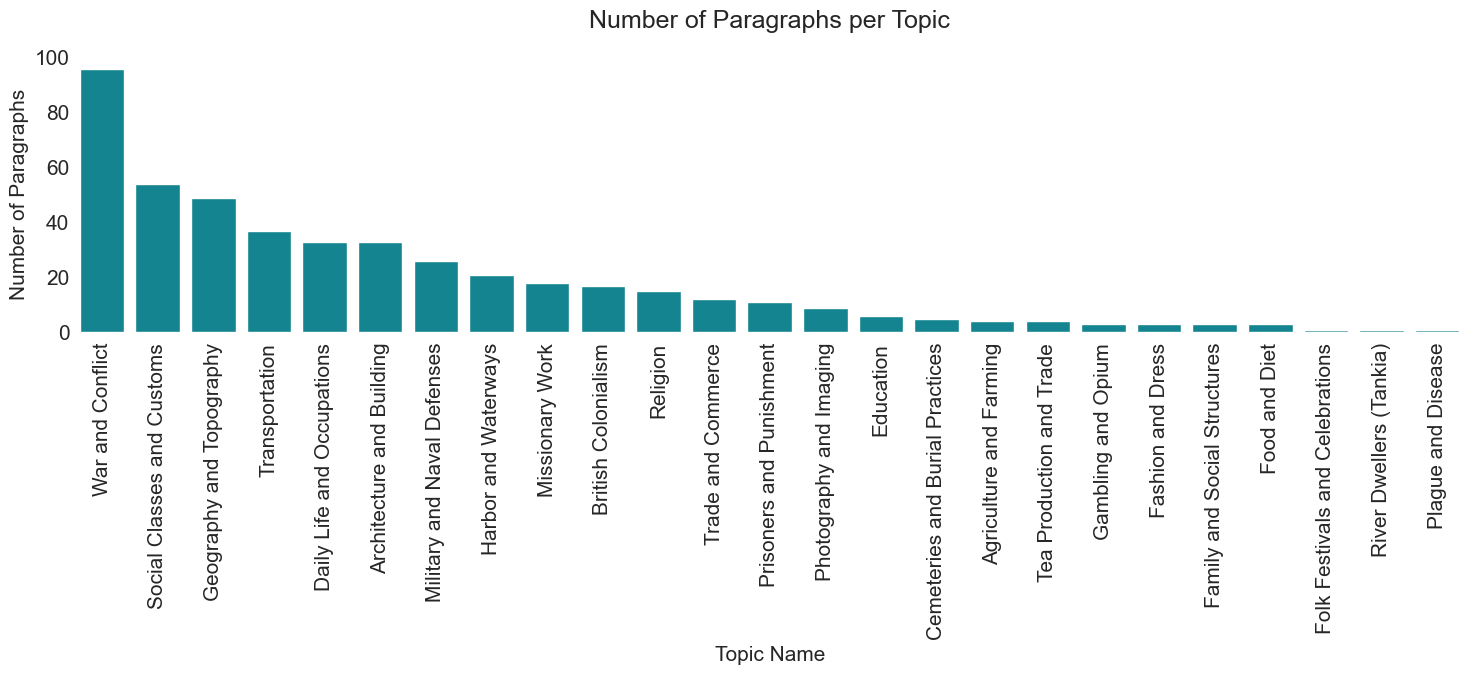

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']
plt.rcParams.update({'font.size': 15})

sns.set_style("white") 
plt.figure(figsize=(15, 7)) 

ax = sns.barplot(x='class_name', y="number", data=df,
                 color='#0094a6') 

plt.ylabel('Number of Paragraphs') 
sns.despine(left=True, bottom=True, top=True, right=True)
plt.xlabel('Topic Name')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
ax.tick_params(axis='x', rotation=90)
plt.title('Number of Paragraphs per Topic', pad=20)

plt.tight_layout()
plt.show()